# **Step 0 : Import Library and call api of earth engine**

In [ ]:
!pip install rasterio
!pip install cartopy

https://tutorials.geemap.org/ImageCollection/visualizing_time_series/

https://wri-projects.s3.amazonaws.com/AqueductFloodTool/download/v2/index.html

In [ ]:
import ee
import geemap
import geopandas as gpd
import os
from pathlib import Path
import rasterio
import matplotlib.pyplot as plt
from rasterio.mask import mask
import cartopy.crs as ccrs
import numpy as np
from shapely.geometry import mapping

In [ ]:
phl_shp_path = "PHL_adm2.shp"
metro_shp_path = "Metro_Manila_Box.shp"

phl_gdf = gpd.read_file(phl_shp_path)
metro_gdf = gpd.read_file(metro_shp_path)


# Ensure CRS is EPSG:4326 (WGS84)
if phl_gdf.crs != "EPSG:4326":
    phl_gdf = phl_gdf.to_crs("EPSG:4326")
if metro_gdf.crs != "EPSG:4326":
    metro_gdf = metro_gdf.to_crs("EPSG:4326")


# **Step 1: First Scenario: inuncoast_historical_nosub_hist_rp0025_0**

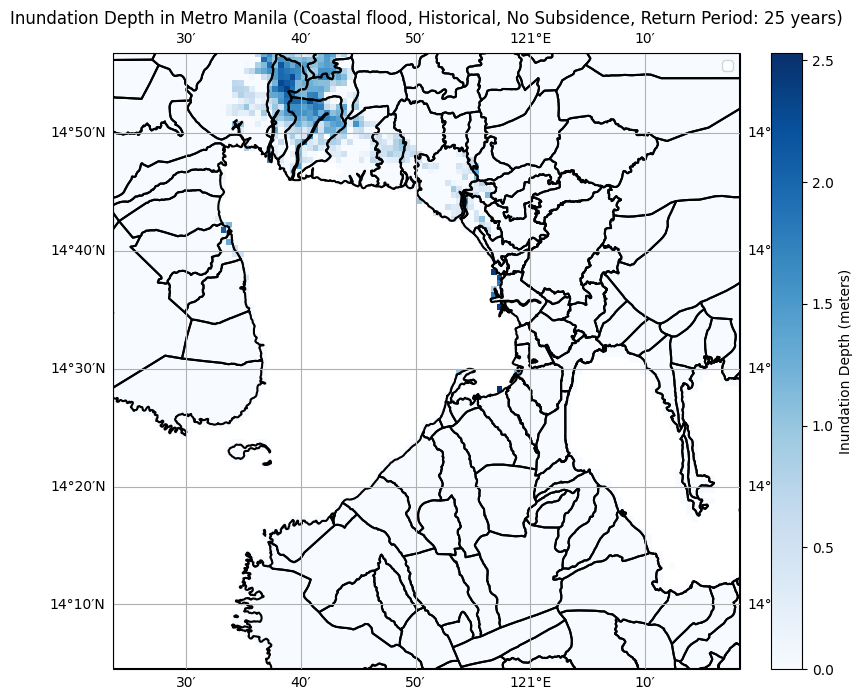

In [ ]:
tiff_path = "inuncoast_historical_nosub_hist_rp0025_0.tif"

# Load and crop TIFF using Metro Manila shapefile
with rasterio.open(tiff_path) as src:
    # Ensure TIFF CRS matches shapefile
    if src.crs != "EPSG:4326":
        print("Warning: TIFF CRS differs. Consider reprojecting the TIFF to EPSG:4326 using gdalwarp.")
    # Crop TIFF to Metro Manila
    metro_geom = [mapping(geom) for geom in metro_gdf.geometry]
    out_image, out_transform = mask(src, metro_geom, crop=True, nodata=np.nan)
    out_meta = src.meta.copy()
    out_meta.update({
        "driver": "GTiff",
        "height": out_image.shape[1],
        "width": out_image.shape[2],
        "transform": out_transform
    })

# Create map
fig = plt.figure(figsize=(10, 8))
ax = plt.axes(projection=ccrs.PlateCarree())

# Plot cropped inundation depth
img = ax.imshow(out_image[0], origin="upper", transform=ccrs.PlateCarree(),
                extent=(out_transform.c, out_transform.c + out_transform.a * out_image.shape[2],
                        out_transform.f + out_transform.e * out_image.shape[1], out_transform.f),
                cmap="Blues", vmin=0, vmax=np.nanmax(out_image) if not np.all(np.isnan(out_image)) else 1)

# Add colorbar
cbar = plt.colorbar(img, ax=ax, orientation="vertical", fraction=0.046, pad=0.04)
cbar.set_label("Inundation Depth (meters)")

# Plot Metro Manila boundary
metro_gdf.boundary.plot(ax=ax, color="black", linewidth=1.5)

# Plot Philippines boundary
phl_gdf.boundary.plot(ax=ax, color="black", linewidth=1.5)

# Add title and legend
plt.title("Inundation Depth in Metro Manila (Coastal flood, Historical, No Subsidence, Return Period: 25 years)")
ax.legend()

# Set extent to Metro Manila bounds
bounds = metro_gdf.total_bounds
ax.set_extent([bounds[0], bounds[2], bounds[1], bounds[3]], crs=ccrs.PlateCarree())

# Add gridlines
ax.gridlines(draw_labels=True, dms=True, x_inline=False, y_inline=False)

# Save and show plot
plt.savefig("First Scenario inuncoast_historical_nosub_hist_rp0025_0.png", dpi=300, bbox_inches="tight")
plt.show()

# **Step 2: Second Scenario: inuncoast_historical_nosub_hist_rp0100_0**

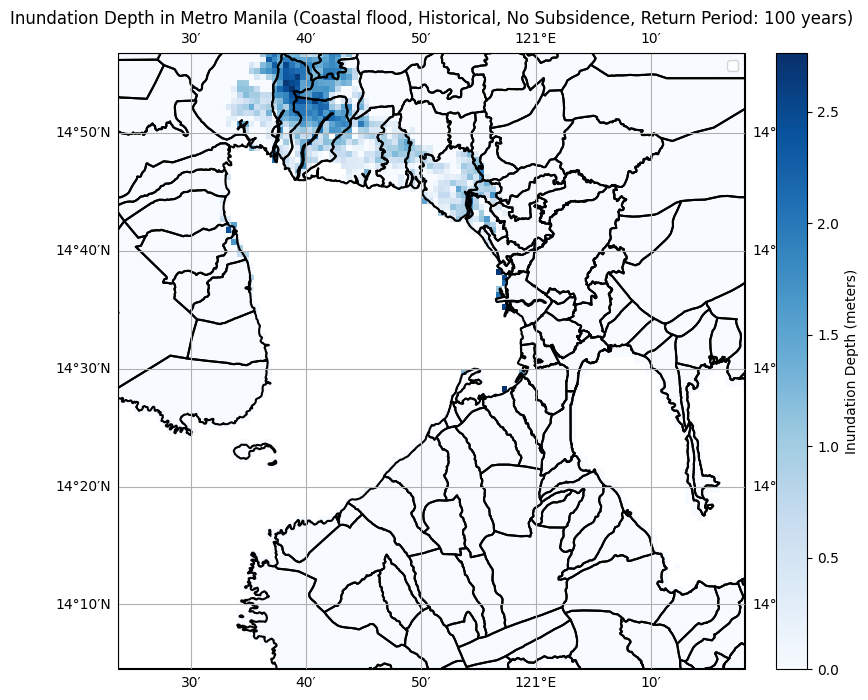

In [ ]:
tiff_path2 = "inuncoast_historical_nosub_hist_rp0100_0.tif"

# Load and crop TIFF using Metro Manila shapefile
with rasterio.open(tiff_path2) as src:
    # Ensure TIFF CRS matches shapefile
    if src.crs != "EPSG:4326":
        print("Warning: TIFF CRS differs. Consider reprojecting the TIFF to EPSG:4326 using gdalwarp.")
    # Crop TIFF to Metro Manila
    metro_geom = [mapping(geom) for geom in metro_gdf.geometry]
    out_image, out_transform = mask(src, metro_geom, crop=True, nodata=np.nan)
    out_meta = src.meta.copy()
    out_meta.update({
        "driver": "GTiff",
        "height": out_image.shape[1],
        "width": out_image.shape[2],
        "transform": out_transform
    })

# Create map
fig = plt.figure(figsize=(10, 8))
ax = plt.axes(projection=ccrs.PlateCarree())

# Plot cropped inundation depth
img = ax.imshow(out_image[0], origin="upper", transform=ccrs.PlateCarree(),
                extent=(out_transform.c, out_transform.c + out_transform.a * out_image.shape[2],
                        out_transform.f + out_transform.e * out_image.shape[1], out_transform.f),
                cmap="Blues", vmin=0, vmax=np.nanmax(out_image) if not np.all(np.isnan(out_image)) else 1)

# Add colorbar
cbar = plt.colorbar(img, ax=ax, orientation="vertical", fraction=0.046, pad=0.04)
cbar.set_label("Inundation Depth (meters)")

# Plot Metro Manila boundary
metro_gdf.boundary.plot(ax=ax, color="black", linewidth=1.5)

# Plot Philippines boundary
phl_gdf.boundary.plot(ax=ax, color="black", linewidth=1.5)

# Add title and legend
plt.title("Inundation Depth in Metro Manila (Coastal flood, Historical, No Subsidence, Return Period: 100 years)")
ax.legend()

# Set extent to Metro Manila bounds
bounds = metro_gdf.total_bounds
ax.set_extent([bounds[0], bounds[2], bounds[1], bounds[3]], crs=ccrs.PlateCarree())

# Add gridlines
ax.gridlines(draw_labels=True, dms=True, x_inline=False, y_inline=False)

# Save and show plot
plt.savefig("Second Scenario inuncoast_historical_nosub_hist_rp0100_0.png", dpi=300, bbox_inches="tight")
plt.show()

# **Step 3: Third Scenario: inuncoast_rcp8p5_nosub_2050_rp0025_0_perc_50**

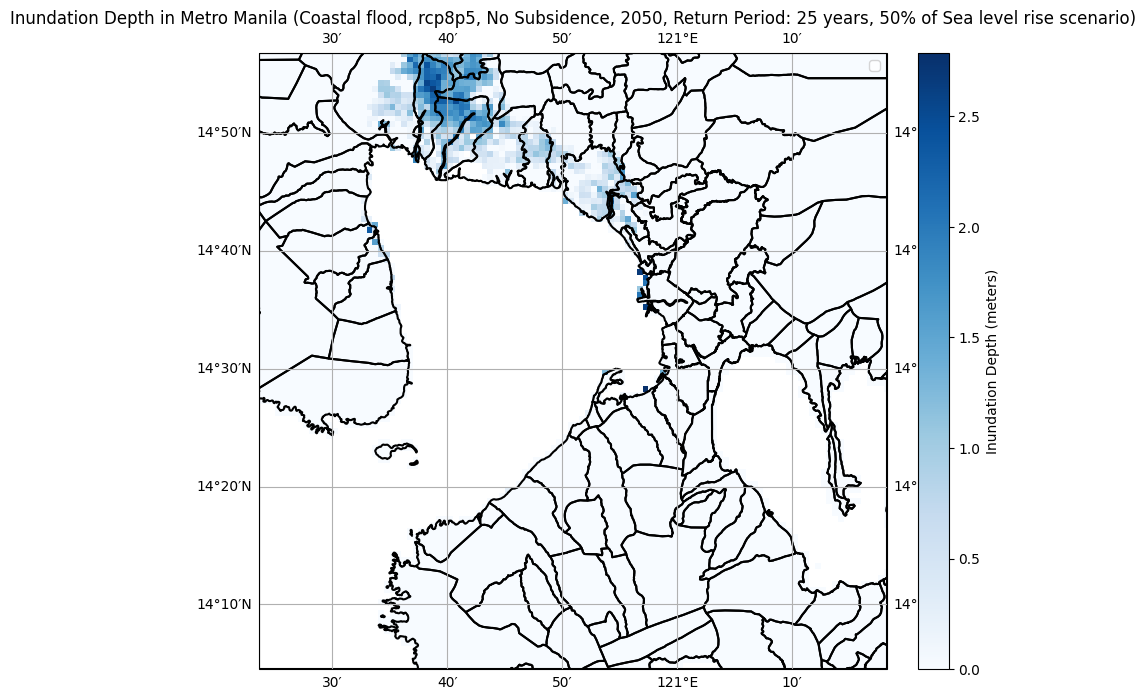

In [ ]:
tiff_path3 = "inuncoast_rcp8p5_nosub_2050_rp0025_0_perc_50.tif"

# Load and crop TIFF using Metro Manila shapefile
with rasterio.open(tiff_path3) as src:
    # Ensure TIFF CRS matches shapefile
    if src.crs != "EPSG:4326":
        print("Warning: TIFF CRS differs. Consider reprojecting the TIFF to EPSG:4326 using gdalwarp.")
    # Crop TIFF to Metro Manila
    metro_geom = [mapping(geom) for geom in metro_gdf.geometry]
    out_image, out_transform = mask(src, metro_geom, crop=True, nodata=np.nan)
    out_meta = src.meta.copy()
    out_meta.update({
        "driver": "GTiff",
        "height": out_image.shape[1],
        "width": out_image.shape[2],
        "transform": out_transform
    })

# Create map
fig = plt.figure(figsize=(10, 8))
ax = plt.axes(projection=ccrs.PlateCarree())

# Plot cropped inundation depth
img = ax.imshow(out_image[0], origin="upper", transform=ccrs.PlateCarree(),
                extent=(out_transform.c, out_transform.c + out_transform.a * out_image.shape[2],
                        out_transform.f + out_transform.e * out_image.shape[1], out_transform.f),
                cmap="Blues", vmin=0, vmax=np.nanmax(out_image) if not np.all(np.isnan(out_image)) else 1)

# Add colorbar
cbar = plt.colorbar(img, ax=ax, orientation="vertical", fraction=0.046, pad=0.04)
cbar.set_label("Inundation Depth (meters)")

# Plot Metro Manila boundary
metro_gdf.boundary.plot(ax=ax, color="black", linewidth=1.5)

# Plot Philippines boundary
phl_gdf.boundary.plot(ax=ax, color="black", linewidth=1.5)

# Add title and legend
plt.title("Inundation Depth in Metro Manila (Coastal flood, rcp8p5, No Subsidence, 2050, Return Period: 25 years, 50% of Sea level rise scenario)")
ax.legend()

# Set extent to Metro Manila bounds
bounds = metro_gdf.total_bounds
ax.set_extent([bounds[0], bounds[2], bounds[1], bounds[3]], crs=ccrs.PlateCarree())

# Add gridlines
ax.gridlines(draw_labels=True, dms=True, x_inline=False, y_inline=False)

# Save and show plot
plt.savefig("Third Scenario nuncoast_rcp8p5_nosub_2050_rp0025_0_perc_50.png", dpi=300, bbox_inches="tight")
plt.show()

# **Step 4: Fourth Scenario: inuncoast_rcp8p5_nosub_2050_rp0100_0_perc_50**

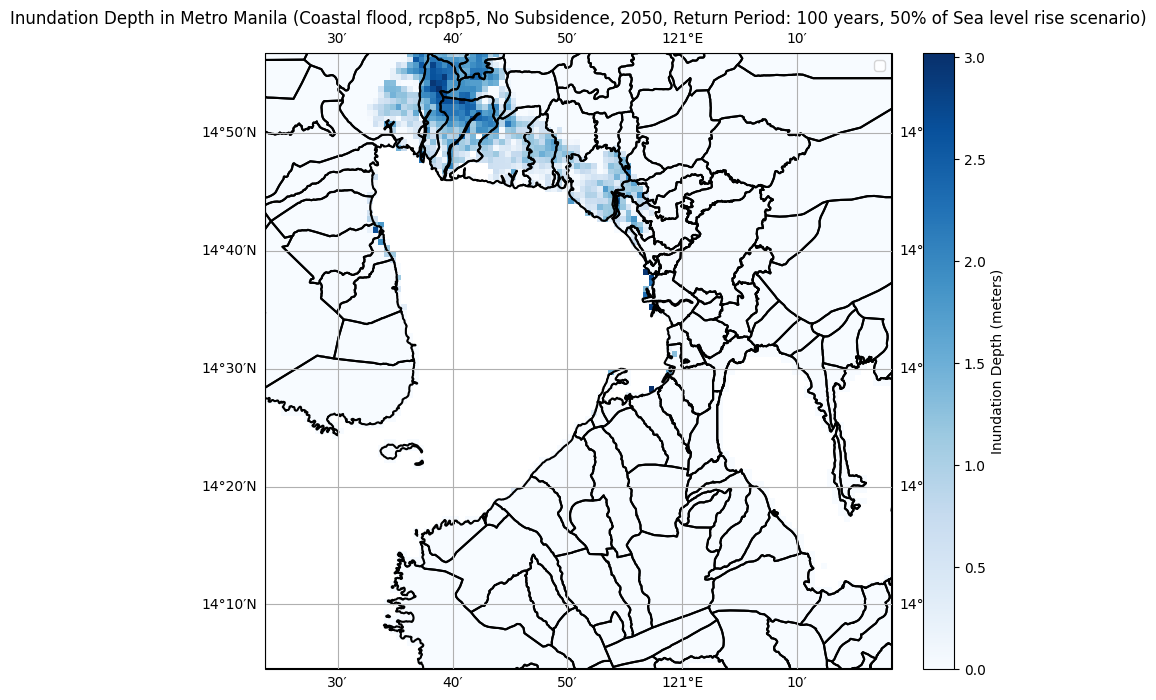

In [ ]:
tiff_path4 = "inuncoast_rcp8p5_nosub_2050_rp0100_0_perc_50.tif"

# Load and crop TIFF using Metro Manila shapefile
with rasterio.open(tiff_path4) as src:
    # Ensure TIFF CRS matches shapefile
    if src.crs != "EPSG:4326":
        print("Warning: TIFF CRS differs. Consider reprojecting the TIFF to EPSG:4326 using gdalwarp.")
    # Crop TIFF to Metro Manila
    metro_geom = [mapping(geom) for geom in metro_gdf.geometry]
    out_image, out_transform = mask(src, metro_geom, crop=True, nodata=np.nan)
    out_meta = src.meta.copy()
    out_meta.update({
        "driver": "GTiff",
        "height": out_image.shape[1],
        "width": out_image.shape[2],
        "transform": out_transform
    })

# Create map
fig = plt.figure(figsize=(10, 8))
ax = plt.axes(projection=ccrs.PlateCarree())

# Plot cropped inundation depth
img = ax.imshow(out_image[0], origin="upper", transform=ccrs.PlateCarree(),
                extent=(out_transform.c, out_transform.c + out_transform.a * out_image.shape[2],
                        out_transform.f + out_transform.e * out_image.shape[1], out_transform.f),
                cmap="Blues", vmin=0, vmax=np.nanmax(out_image) if not np.all(np.isnan(out_image)) else 1)

# Add colorbar
cbar = plt.colorbar(img, ax=ax, orientation="vertical", fraction=0.046, pad=0.04)
cbar.set_label("Inundation Depth (meters)")

# Plot Metro Manila boundary
metro_gdf.boundary.plot(ax=ax, color="black", linewidth=1.5)

# Plot Philippines boundary
phl_gdf.boundary.plot(ax=ax, color="black", linewidth=1.5)

# Add title and legend
plt.title("Inundation Depth in Metro Manila (Coastal flood, rcp8p5, No Subsidence, 2050, Return Period: 100 years, 50% of Sea level rise scenario)")
ax.legend()

# Set extent to Metro Manila bounds
bounds = metro_gdf.total_bounds
ax.set_extent([bounds[0], bounds[2], bounds[1], bounds[3]], crs=ccrs.PlateCarree())

# Add gridlines
ax.gridlines(draw_labels=True, dms=True, x_inline=False, y_inline=False)

# Save and show plot
plt.savefig("Fourth Scenario nuncoast_rcp8p5_nosub_2050_rp0100_0_perc_50.png", dpi=300, bbox_inches="tight")
plt.show()

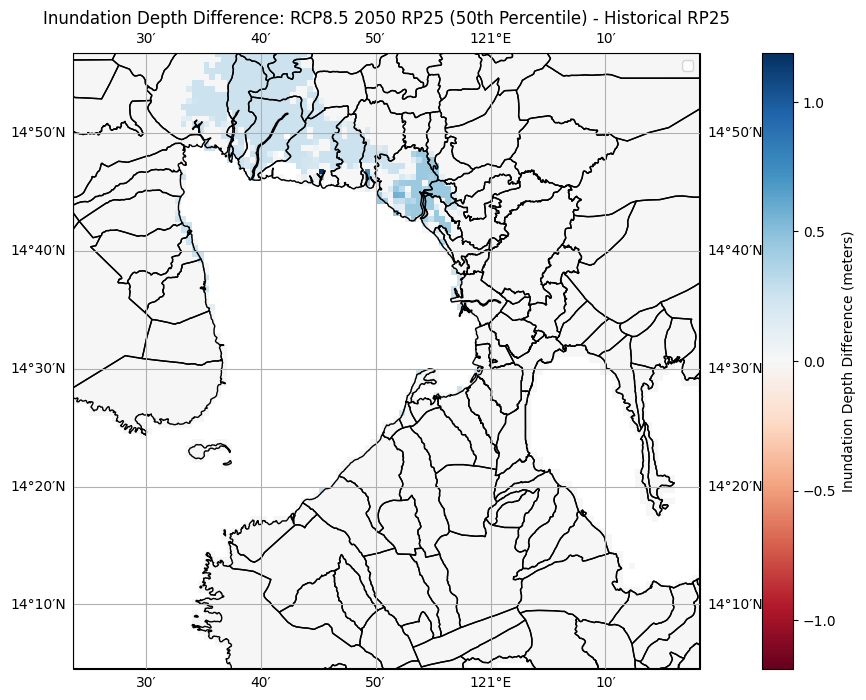

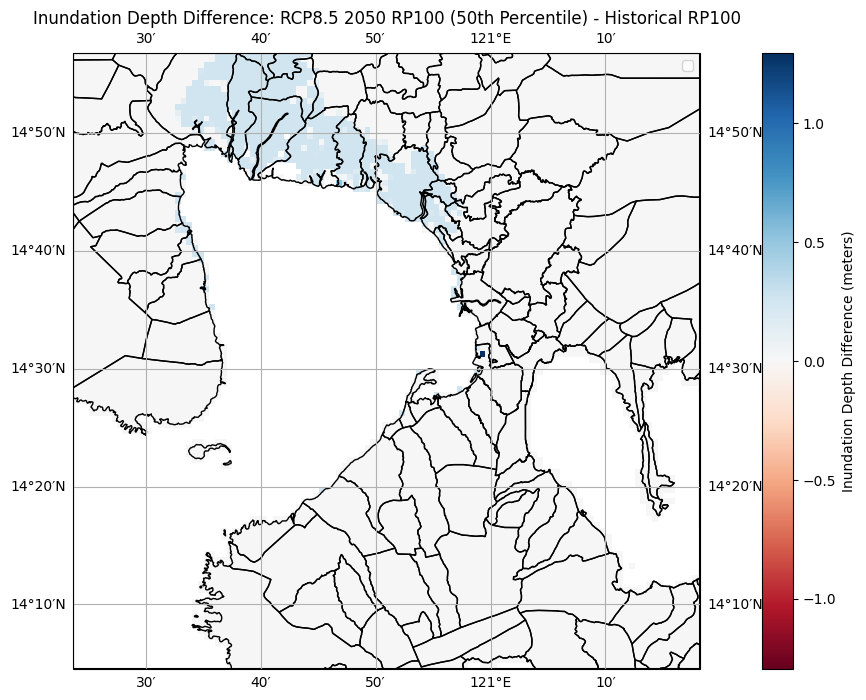

In [ ]:
# Function to crop TIFF and return data and transform
def crop_tiff(tiff_path, geometries):
    with rasterio.open(tiff_path) as src:
        if src.crs != "EPSG:4326":
            print(f"Warning: {tiff_path} CRS differs. Consider reprojecting to EPSG:4326 using gdalwarp.")
        out_image, out_transform = mask(src, geometries, crop=True, nodata=np.nan)
        return out_image[0], out_transform  # Return single band and transform

metro_geom = [mapping(geom) for geom in metro_gdf.geometry]
img1, transform1 = crop_tiff(tiff_path, metro_geom)  # First Scenario
img3, transform3 = crop_tiff(tiff_path2, metro_geom)  # Third Scenario
img2, transform2 = crop_tiff(tiff_path3, metro_geom)  # Second Scenario
img4, transform4 = crop_tiff(tiff_path4, metro_geom)  # Fourth Scenario

# Calculate differences
diff1 = img3 - img1
diff2 = img4 - img2

# Function to plot difference map
def plot_difference_map(diff_data, transform, title, output_file):
    fig = plt.figure(figsize=(20, 8))
    ax = plt.axes(projection=ccrs.PlateCarree())

    # Determine colorbar range (symmetric around 0)
    max_abs = np.nanmax(np.abs(diff_data)) if not np.all(np.isnan(diff_data)) else 1
    vmin, vmax = -max_abs, max_abs

    # Plot difference
    img = ax.imshow(diff_data, origin="upper", transform=ccrs.PlateCarree(),
                    extent=(transform.c, transform.c + transform.a * diff_data.shape[1],
                            transform.f + transform.e * diff_data.shape[0], transform.f),
                    cmap="RdBu", vmin=vmin, vmax=vmax)

    # Add colorbar
    cbar = plt.colorbar(img, ax=ax, orientation="vertical", fraction=0.046, pad=0.04)
    cbar.set_label("Inundation Depth Difference (meters)")

    # Plot Metro Manila boundary
    metro_gdf.boundary.plot(ax=ax, color="black", linewidth=1.5)

    # Plot Philippines boundary
    phl_gdf.boundary.plot(ax=ax, color="black", linewidth=1)

    # Add title and legend
    plt.title(title)
    ax.legend()

    # Set extent to Metro Manila bounds
    bounds = metro_gdf.total_bounds
    ax.set_extent([bounds[0], bounds[2], bounds[1], bounds[3]], crs=ccrs.PlateCarree())

    # Add gridlines
    ax.gridlines(draw_labels=True, dms=True, x_inline=False, y_inline=False)

    # Save and show
    plt.savefig(output_file, dpi=300, bbox_inches="tight")
    plt.show()

# Plot Difference 1
plot_difference_map(diff1, transform3,
                   "Inundation Depth Difference: RCP8.5 2050 RP25 (50th Percentile) - Historical RP25",
                   "difference_map_1.png")

# Plot Difference 2
plot_difference_map(diff2, transform2,
                   "Inundation Depth Difference: RCP8.5 2050 RP100 (50th Percentile) - Historical RP100",
                   "difference_map_2.png")